In [53]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel,Field
from typing import TypedDict,Literal
from langchain_google_genai import ChatGoogleGenerativeAI
load_dotenv()

True

In [54]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int
    eqn:str
    d:float
    result:str

In [55]:
def show_eqn(state:QuadState):
    eqn =  f"{state["a"]}X2 + {state["b"]}X + {state["c"]}"
    state["eqn"] = eqn 
    return {"eqn":eqn}

def calculate_discriminant(state:QuadState):
    discriminant = (state["b"]**2)-(4*state["a"]*state["c"])
    state["d"] = discriminant
    return {"d":discriminant}

def check_condition(state:QuadState)->Literal["realRoot","equalRoot","noRealRoot"]:
    d = state["d"]
    if(d>0):
        return "realRoot"
    
    elif(d==0):
        return "equalRoot"
    
    else:
        return "noRealRoot"

def real_root(state:QuadState):
    r1 = (-state["b"] + (state["d"])**0.5 )/(2*state["a"])
    r2 = (-state["b"] - (state["d"])**0.5 )/(2*state["a"])

    result = f"Rotts are {r1} and {r2}"
    state["result"] = result
    return {"result":result}
def equal_root(state:QuadState):
    r = (-state["b"])/(2*state["a"])

    result = f"Rotts are {r}"
    state["result"] = result
    return {"result":result}
def no_real_root(state:QuadState):
    
    result = f"Rotts are not real "
    state["result"] = result
    return {"result":result}
    

In [56]:
graph = StateGraph(QuadState)

graph.add_node("showEqn",show_eqn)
graph.add_node("calculateDiscriminant",calculate_discriminant)
graph.add_node("realRoot",real_root)
graph.add_node("equalRoot",equal_root)
graph.add_node("noRealRoot",no_real_root)



In [57]:
graph.add_edge(START,"showEqn")
graph.add_edge("showEqn","calculateDiscriminant")
graph.add_conditional_edges("calculateDiscriminant",check_condition)
graph.add_edge("equalRoot",END)
graph.add_edge("realRoot",END)
graph.add_edge("noRealRoot",END)





In [58]:
workflow = graph.compile()

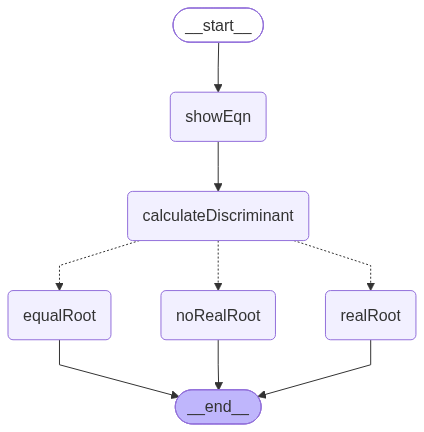

In [59]:
workflow

In [60]:
results = workflow.invoke({
    "a":1,
    "b":-2,
    "c":1
})


In [61]:
results

{'a': 1,
 'b': -2,
 'c': 1,
 'eqn': '1X2 + -2X + 1',
 'd': 0,
 'result': 'Rotts are 1.0'}